<a href="https://colab.research.google.com/github/TanyaGandhi/ai-debugging-rca-platform/blob/feature/ai_debugging_rca_platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI-Powered Microservice Debugging & RCA Platform

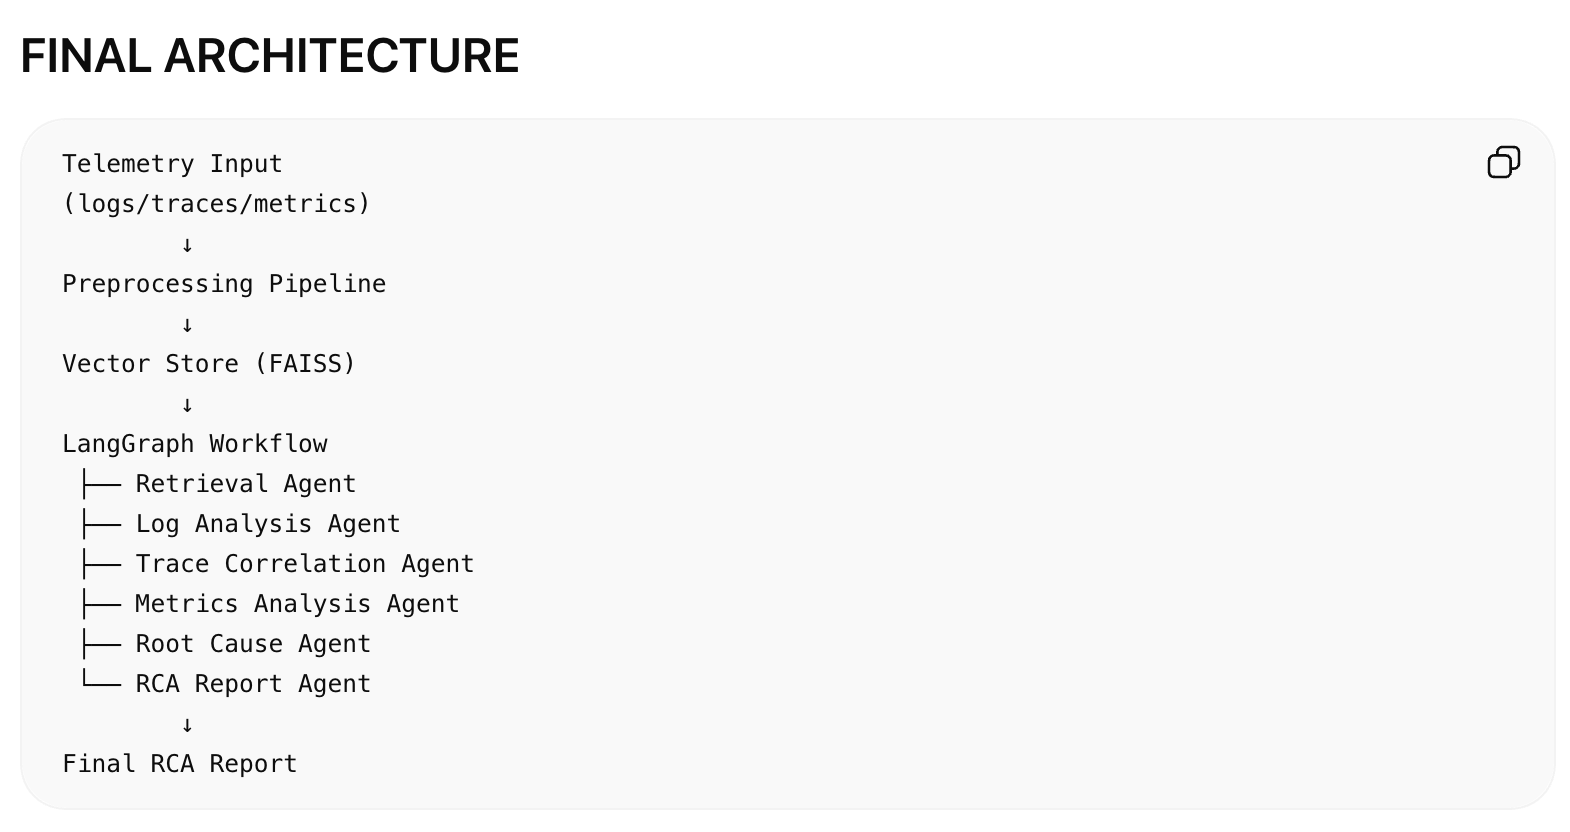

**SECTION 1 — Install Packages**

In [4]:
!pip install -q \
langchain \
langgraph \
langchain-google-genai \
faiss-cpu \
pydantic \
pandas \
numpy \
tiktoken \
fastapi \
uvicorn \
python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 50.1 MB/s eta 0:00:00


**Configure Gemini**

In [6]:
import os
from google.colab import userdata
import google.genai as genai
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

**Create Gemini Model**

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model ="gemini-2.5-flash",
    temperature = 0
)

**SECTION 2 — Build Realistic Telemetry Generator**

In [8]:
#Example Log Dataset
logs = [
    {
        "timestamp": "2026-05-15T10:01:00",
        "service": "payment-service",
        "level": "ERROR",
        "message": "Database connection timeout"
    },
    {
        "timestamp": "2026-05-15T10:01:02",
        "service": "order-service",
        "level": "ERROR",
        "message": "Payment processing failed"
    }
]
#Example Trace Dataset
traces = [
    {
        "trace_id": "abc123",
        "source": "api-gateway",
        "destination": "payment-service",
        "latency_ms": 4200,
        "status": "TIMEOUT"
    }
]
#Example Metrics Dataset
metrics = [
    {
        "service": "payment-service",
        "cpu_usage": 92,
        "memory_usage": 88,
        "error_rate": 34
    }
]
#Example Stack Trace Dataset
stack_traces = [
    {
        "service": "payment-service",
        "stack_trace": """
        ConnectionPoolExhaustedException:
        Unable to acquire JDBC
        """
    }
      ]

Step 2.1 — Create Service Dependency Graph

In [9]:
SERVICE_GRAPH = {
    "api-gateway" : ["auth-service", "order-service"],
    "order-service" : ["payment-service", "inventory-service"],
    "payment-service": ["db-service"],
    "inventory-service": ["db-service"],
    "auth-service": ["redis-cache"]
}

Step 2.2 — Generate Synthetic Failures

In [10]:
import random
from datetime import datetime, timezone # Add timezone here
import uuid

SERVICES = [
    "api-gateway",
    "auth-service",
    "order-service",
    "payment-service",
    "inventory-service",
    "db-service"
]

ERROR_PATTERNS = [
    "Database connection timeout",
    "Connection pool exhausted",
    "Kafka consumer lag exceeded threshold",
    "HTTP 503 Service Unavailable",
    "Redis cache miss spike",
    "gRPC request timeout",
    "Thread pool saturation",
    "Out of memory error"
]

Step 2.3 — Generate Logs

In [11]:
def generate_logs(num_log=200):
  logs = []
  for _ in range(num_log):
    service = random.choice(SERVICES)
    is_error = random.random() < 0.3
    logs.append(
        {
            "timestamp" :  str(datetime.now(timezone.utc)),
            "trace_id":  str(uuid.uuid4()),
            "service": service,
            "level": "ERROR" if is_error else "INFO",
            "message": random.choice(ERROR_PATTERNS) if is_error else "Request processed successfully"
        }
    )
    return logs

Step 2.4 — Generate Distributed Traces

In [12]:
def generate_traces(num_traces =100):
  traces = []
  for _ in range(num_traces):
    source = random.choice(list(SERVICE_GRAPH.keys()))
    if SERVICE_GRAPH.get(source):
      destination = random.choice(SERVICE_GRAPH.get(source))
    else:
      destination = "unknown"
    latency = random.randint(10,5000)
    traces.append(
        {
            "trace_id": str(uuid.uuid4()),
            "source" : source,
            "destination": destination,
            "latency_ms": latency,
            "status": "TIMEOUT" if latency > 3000 else "SUCCESS"
        }
    )
    return traces



Step 2.5 — Generate Metrics

In [13]:
def generate_metrics():
  metrics = []
  for service in SERVICES:

    cpu = random.randint(20,98)
    metrics.append({
        "service": service,
        "cpu": cpu,
        "memory_usage": random.randint(20,95),
        "error_rate": random.randint(0,40),
        "request_count": random.randint(100,5000),
        "p95_latency": random.randint(50,4000)
    })

  return metrics


Step 2.6 — Generate Stack Traces

In [14]:
STACK_TRACES = [
    """
    java.sql.SQLTimeoutException:
    Connection pool exhausted
    at payment.service.DatabaseConnector.getConnection
    """,

    """
    NullPointerException:
    order object is null
    at OrderProcessor.processOrder
    """,

    """
    KafkaTimeoutException:
    Failed to update metadata
    """
]

def generate_stack_traces():
    traces = []

    for _ in range(20):

        traces.append({
            "service": random.choice(SERVICES),
            "stack_trace": random.choice(STACK_TRACES)
        })

    return traces

Step 2.7 — Create Telemetry Dataset

In [15]:
logs = generate_logs()
traces = generate_traces()
metrics = generate_metrics()
stack_traces = generate_stack_traces()

Step 2.8 — Save Datasets

In [16]:
import json

with open("logs.json", "w") as f:
    json.dump(logs, f)

with open("traces.json", "w") as f:
    json.dump(traces, f)

with open("metrics.json", "w") as f:
    json.dump(metrics, f)

with open("stack_traces.json", "w") as f:
    json.dump(stack_traces, f)

**SECTION 3 — Build RAG Pipeline**

Step 3.1 — Install Embedding Support

In [17]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


Step 3.2 — Create Documents

In [18]:
from langchain_core.documents import Document

documents = []

for log in logs:
    documents.append(
        Document(
            page_content=str(log),
            metadata={"type": "log"}
        )
    )

for trace in stack_traces:
    documents.append(
        Document(
            page_content=str(trace),
            metadata={"type": "stack_trace"}
        )
    )

Step 3.3 — Add Troubleshooting KB

In [19]:
kb_docs = [
    """
    Database connection timeout usually occurs due to:
    - exhausted DB pool
    - slow queries
    - network latency
    Recommended actions:
    increase pool size,
    optimize queries,
    add retries
    """,

    """
    Kafka consumer lag occurs due to:
    - slow consumers
    - broker overload
    - partition imbalance
    Recommended fixes:
    scale consumers,
    tune batch size
    """
]

for kb in kb_docs:
    documents.append(
        Document(
            page_content=kb,
            metadata={"type": "kb"}
        )
    )

Step 3.4 — Create Gemini Embeddings

In [25]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(model="text-embedding-004")